In [1]:
from plotnine import *
import polars as pl
from mizani.formatters import scientific_format, custom_format
import math
import pyarrow

theme_set(theme_matplotlib())

In [2]:
DF = pl.read_csv("overhead_results.csv")

In [3]:
DF_PLOT = DF.rename({"avg_dynm_exec_ns": "PGO", "avg_symb_exec_ns": "Symbolic"}).unpivot(
    on=["PGO", "Symbolic"], index=["label", "size"]
)
DF_PLOT = DF_PLOT.with_columns(
    (pl.col("value") / 1_000_000).alias("value")
)

In [4]:
DF_PLOT

label,size,variable,value
str,i64,str,f64
"""conv""",64,"""PGO""",20.81168
"""conv""",128,"""PGO""",89.080654
"""conv""",256,"""PGO""",381.515114
"""conv""",512,"""PGO""",1488.722869
"""conv""",1024,"""PGO""",5994.512278
…,…,…,…
"""transpose""",512,"""Symbolic""",0.537805
"""transpose""",1024,"""Symbolic""",0.601534
"""transpose""",2048,"""Symbolic""",0.524003


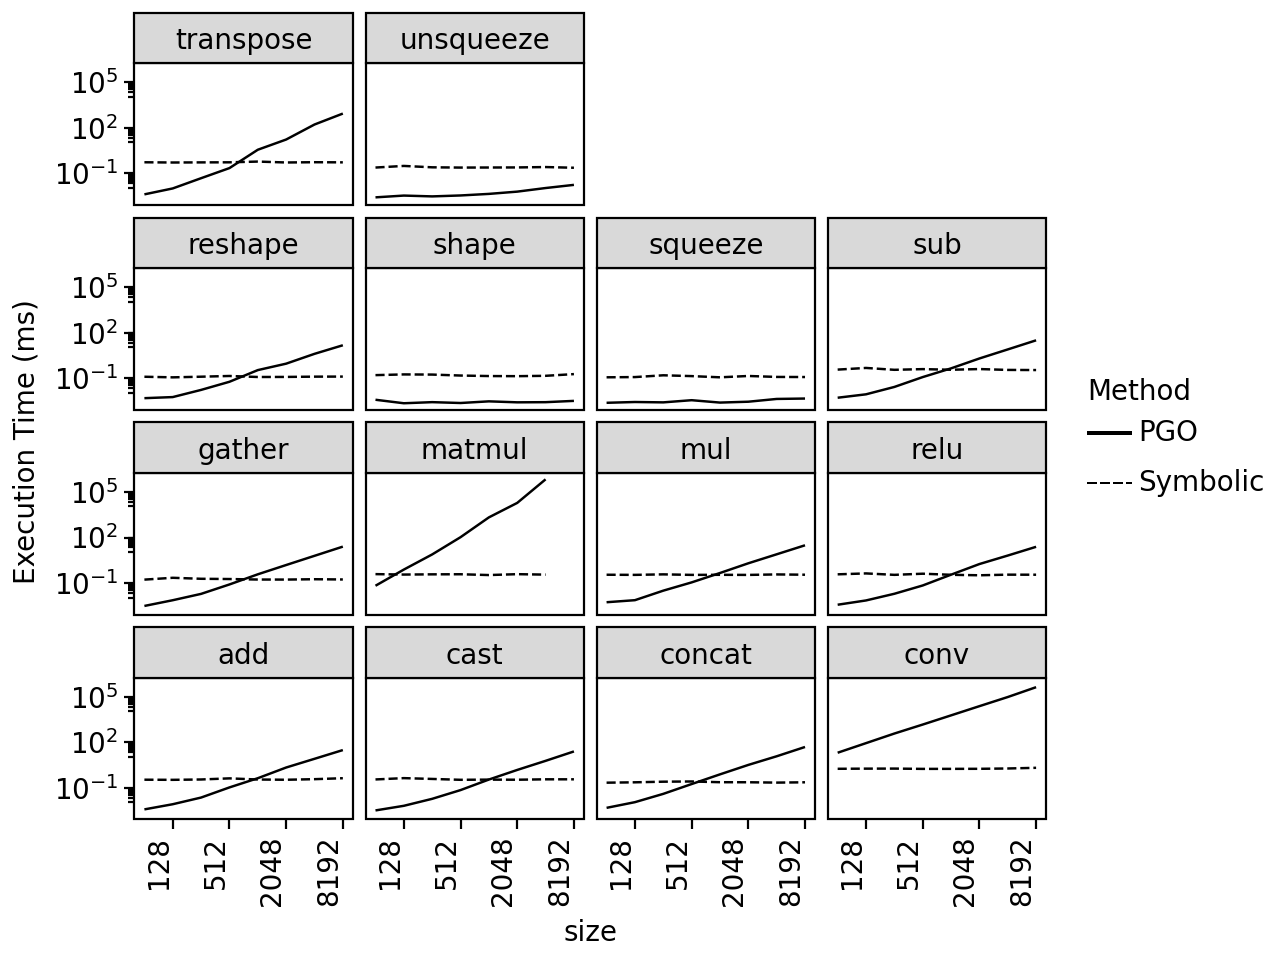

In [ ]:
PLOT = (
    ggplot(
        data=DF_PLOT, 
        mapping=aes(x="size", y="value")
    )
    + geom_line(mapping=aes(linetype="variable"))
    + facet_wrap("label", as_table=False)
    + scale_x_continuous(trans="log2", labels=lambda vals: [f"{v:.0f}" for v in vals])
    + scale_y_log10(labels=lambda vals: [rf"$10^{{{int(round(math.log10(v)))}}}$" for v in vals])
    + labs(y="Execution Time (ms)", linetype="Method", shape="Method")
    + theme(
        axis_text_x=element_text(rotation=90, hjust=1),
        legend_position="top")
)
PLOT

In [ ]:
PLOT.save("all-exec.pdf")

/home/jingyuqiu/projects/venv/default/lib/python3.12/site-packages/plotnine/ggplot.py:630: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jingyuqiu/projects/venv/default/lib/python3.12/site-packages/plotnine/ggplot.py:631: PlotnineWarning: Filename: all-exec.pdf
